In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import sys
import json
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
import numpy as np
import time
from mace.calculators import MACECalculator
from pymatgen.io.vasp.outputs import Vasprun
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
from sklearn.mixture import GaussianMixture
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from pymatgen.core import Structure
from dscribe.descriptors import SOAP
from ase.build import molecule
from sklearn.decomposition import PCA

In [14]:
# Figure Information
plt.style.use('default')
colors = ['#E9C5DD', '#C5A7C1', '#A18AA5', '#7E6E8A', '#5C5470', '#3B3657']
plt.rc('font', size=18)
plt.rc('axes', titlesize=22)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('legend', fontsize=18)
plt.rc('figure', titlesize=15)
plt.rcParams['axes.linewidth'] = 3

In [15]:
class DFTInfo():
    def __init__(self, structure, forces, stress, energy, success=True):
        self.structure = structure
        self.forces = forces
        self.stress = stress
        self.energy = energy
        self.success = success
    def __str__(self):
        return self.structure, self.forces, self.energy
    def xyz_forces(self):
        if not self.success:
            return None
        arr = []
        for site, force in zip(self.structure.sites, self.forces):
            arr.append(np.concatenate([site.coords, force]))
        return np.array(arr)
    def from_json(cls, json_path):
        try:
            with open(json_path, "r") as f:
                data = json.load(f)
            structure = Structure.from_dict(data["structure"])
            forces = np.array(data["forces"])
            stress = np.array(data["stress"])
            energy = data["energy"]
            return cls(structure, forces, stress, energy, success=True)
        except Exception as e:
            print(f"Error reading JSON {json_path}: {e}")
            return cls(None, None, None, None, success=False)

In [16]:
def get_DFT_from_directory(dir_path):
    """ Takes in directory, reads in JSON files, and outputs dictionary of (timestep, DFTInfo)
    """
    frames = {}
    for fname in sorted(os.listdir(dir_path)):
        timestep = int(fname.split(".")[1])
        frames[timestep] = DFTInfo.from_json(DFTInfo, os.path.join(dir_path, fname + '/vasp_info.json'))
    return frames

# Models

In [17]:
# Universal Model
U_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:U/model/mace_agnesi_small.model")
# Naive Models
N_10pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pts.model", device='cuda')
N_21pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pts.model", device='cuda')
N_31pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pts.model", device='cuda')
N_40pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pts.model", device='cuda')
N_50pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/50pts.model", device='cuda')
# Periodic Models
FT1_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/ft1.model", device='cuda')
FT2_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft2.model", device='cuda')
FT3_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft3.model", device='cuda')
FT4_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft4.model", device='cuda')
FT5_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft5.model", device='cuda')


/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

...

/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

In [18]:
naive_models = [U_model, N_10pts_model, N_21pts_model, N_31pts_model, N_40pts_model, N_50pts_model]
periodic_models = [U_model, FT1_model, FT2_model, FT3_model, FT4_model, FT5_model]

# Evaluate Training Trajectories

### Read Data

In [19]:
U_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:U/dft")
FT1_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT1/dft")
FT2_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT2/dft")
FT3_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT3/dft")
FT4_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT4/dft")
FT5_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT5/dft")
U_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:U/md/run_info.txt", sep = '\t')
FT1_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT1/md/run_info.txt", sep = '\t')
FT2_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT2/md/run_info.txt", sep = '\t')
FT3_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT3/md/run_info.txt", sep = '\t')
FT4_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT4/md/run_info.txt", sep = '\t')
FT5_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT5/md/run_info.txt", sep = '\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT, FT3_Train_DFT, FT4_Train_DFT, FT5_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD, FT3_Train_MD, FT4_Train_MD, FT5_Train_MD]

### Generate Plot

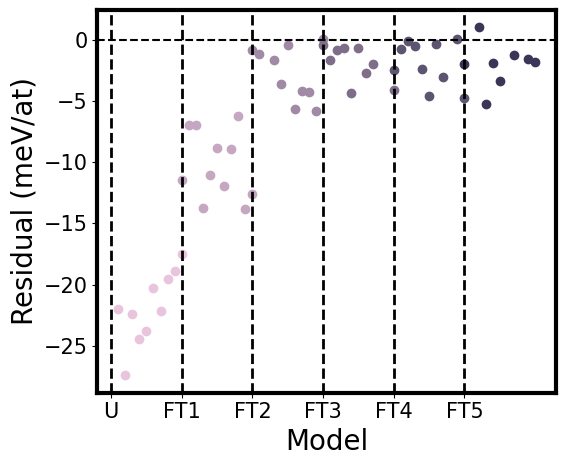

In [20]:
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
# ax.axvline(x=7, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./figures/trainingEvaluation.svg")

# Evaluate Test Sets

Allow each model to start from the same place, then we plot the difference in energy predictions

## Read Data

In [21]:
U_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/U/dft")
FT1_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT1/dft")
FT2_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT2/dft")
FT3_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT3/dft")
FT4_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT4/dft")
FT5_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT5/dft")
N_10pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-10pts/dft")
N_21pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-21pts/dft")
N_31pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-31pts/dft")
N_40pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-40pts/dft")
N_50pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-50pts/dft")
U_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/U/md/run_info.txt", sep='\t')
FT1_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT4/md/run_info.txt", sep='\t')
FT5_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT5/md/run_info.txt", sep='\t')
N_10pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-10pts/md/run_info.txt", sep='\t')
N_21pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-21pts/md/run_info.txt", sep='\t')
N_31pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-31pts/md/run_info.txt", sep='\t')
N_40pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-40pts/md/run_info.txt", sep='\t')
N_50pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-50pts/md/run_info.txt", sep='\t')


In [22]:
Naive_Eval_DFT = [U_Eval_DFT, N_10pts_Eval_DFT, N_21pts_Eval_DFT, N_31pts_Eval_DFT, N_40pts_Eval_DFT, N_50pts_Eval_DFT]
Naive_Eval_MD = [U_Eval_MD, N_10pts_Eval_MD, N_21pts_Eval_MD, N_31pts_Eval_MD, N_40pts_Eval_MD, N_50pts_Eval_MD]
Periodic_Eval_DFT = [U_Eval_DFT, FT1_Eval_DFT, FT2_Eval_DFT, FT3_Eval_DFT, FT4_Eval_DFT, FT5_Eval_DFT]
Periodic_Eval_MD = [U_Eval_MD, FT1_Eval_MD, FT2_Eval_MD, FT3_Eval_MD, FT4_Eval_MD, FT5_Eval_MD]

In [23]:
atoms = read("../data/ChClCA_Evaluations/Periodic/FT5/md/ft5_eval_ase.xyz", "::100")

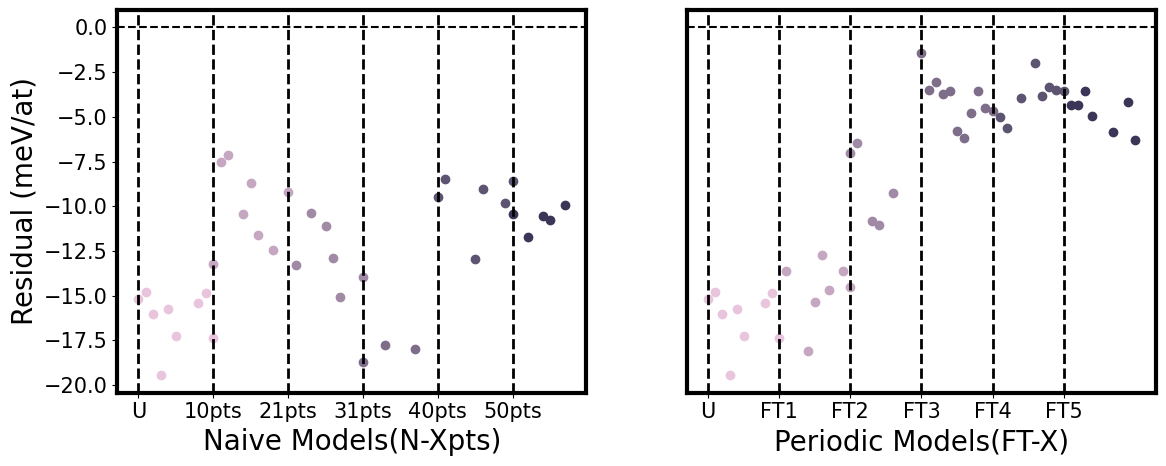

In [24]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5), sharey=False)
# Left plot, Naive
for idx, trajectory in enumerate(zip(Naive_Eval_DFT, Naive_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[0].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
# Right plot, Periodic
for idx, trajectory in enumerate(zip(Periodic_Eval_DFT, Periodic_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[1].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax[1].set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax[0].set_xticks(np.arange(1,7), ['U', '10pts', '21pts', '31pts', '40pts', '50pts'])
ax[0].axhline(y=0, linestyle='--', color='black')
ax[1].axhline(y=0, linestyle='--', color='black')
ax[0].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
ax[1].tick_params(axis='y', which='both', color=(0,0,0,0))
ax[0].set_xlabel("Naive Models(N-Xpts)")
ax[1].set_xlabel("Periodic Models(FT-X)")
ax[0].set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./figures/results_modelEvaluations.svg")

In [25]:
U_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/U/dft")
FT1_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT1/dft")
FT2_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT2/dft")
FT3_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT3/dft")
U_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/U/md/run_info.txt", sep='\t')
FT1_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT3/md/run_info.txt", sep='\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT, FT3_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD, FT3_Train_MD]



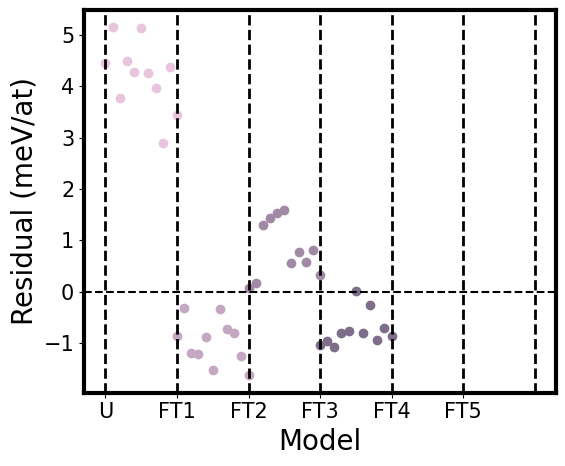

In [26]:
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
ax.axvline(x=7, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()

# SOAP/PCA Exploratory Data Analysis

In [27]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
all_data = naive_set + ft_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)

In [28]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]

# Convert to numpy arrays and flatten 
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft   = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])

# Combine for PCA fit
X_all = np.vstack([X_naive, X_ft])

# Fit PCA on combined data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

# Split back
X_naive_pca = X_pca[:len(X_naive)]
X_ft_pca   = X_pca[len(X_naive):]
explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PC:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Cumulative variance
cumulative_variance = explained_variance.cumsum()
print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Variance captured by each PC:
PC1: 0.2300 (23.00%)
PC2: 0.1882 (18.82%)

Cumulative variance:
PC1 to PC1: 0.2300 (23.00%)
PC1 to PC2: 0.4182 (41.82%)


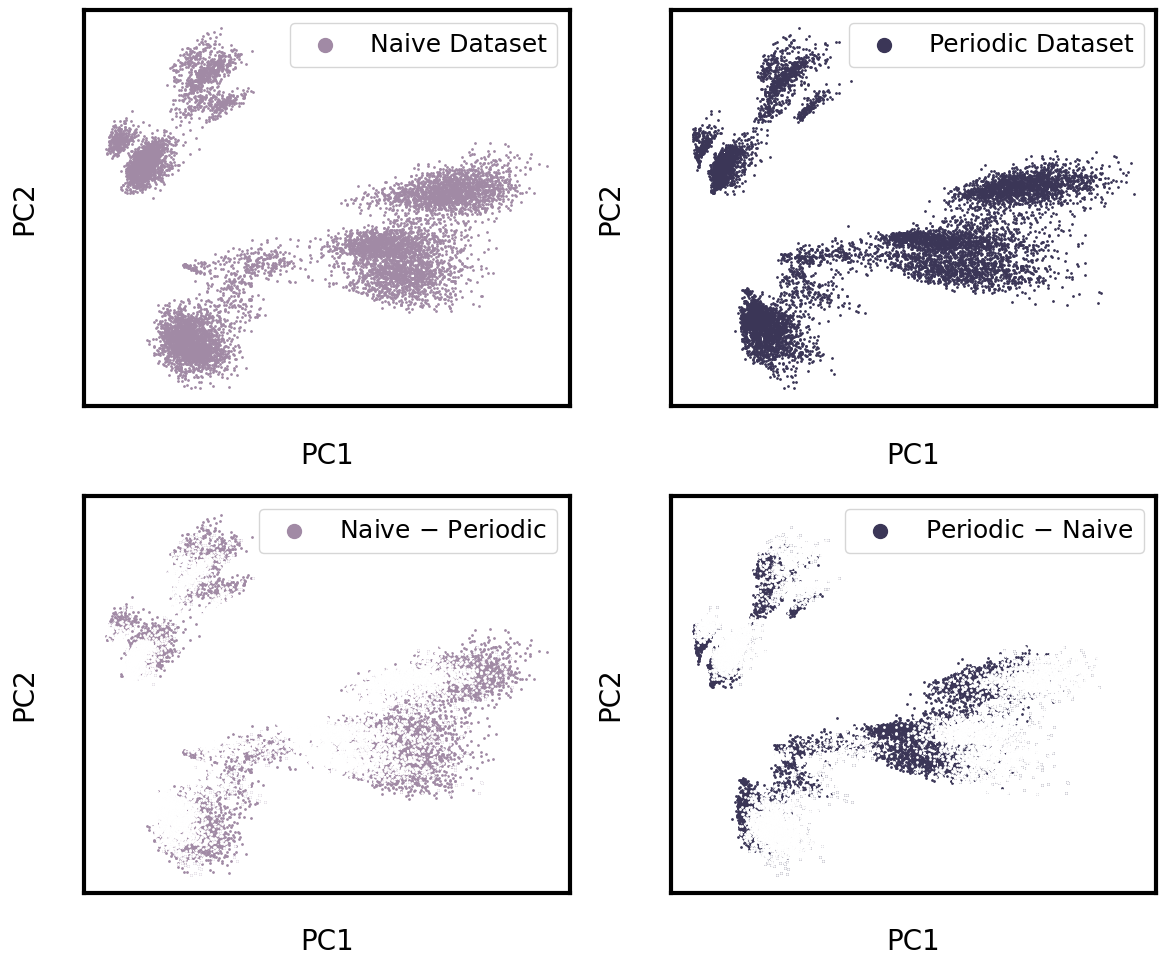

In [29]:
fig, ax = plt.subplots(2, 2, figsize = (12, 10), sharey=False)

ax[0,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[5], 
           label='Periodic Dataset', rasterized=True)
ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label='Naive Dataset', rasterized=True)
ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[5], 
           label=r'Periodic $\minus$ Naive', rasterized=True)
ax[1,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label=r'Naive $\minus$ Periodic', rasterized=True)
ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
for a in ax[1]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
for a in ax[0]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1,1].set_xlabel("PC1")
ax[1,1].set_ylabel("PC2")
ax[1,0].set_xlabel("PC1")
ax[1,0].set_ylabel("PC2")
ax[0,1].set_xlabel("PC1")
ax[0,1].set_ylabel("PC2")
ax[0,0].set_xlabel("PC1")
ax[0,0].set_ylabel("PC2")
ax[1,1].legend(markerscale=10)
ax[1,0].legend(markerscale=10)
ax[0,0].legend(markerscale=10)
ax[0,1].legend(markerscale=10)
fig.tight_layout()
fig.savefig("figures/results_PCA_Datasets.svg")


In [30]:
naive_set = read("/storage/home/hcoda1/0/nwong70/scratch/mace_finetuning/datasets/20250903_MACE-U_ParallelTraining/50pt_dataset/50pt_dataset.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data.xyz", index=':')
ft3_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data.xyz", index=':')
ft2_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data.xyz", index=':')
ft1_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data.xyz", index=':')
u_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data.xyz", index=':')
all_data = naive_set + ft3_set + ft2_set + ft1_set + u_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)

In [31]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft4_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
ft3_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft3_set]
ft2_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft2_set]
ft1_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft1_set]
u_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in u_set]
# Convert to numpy arrays and flatten
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft4   = np.array(ft4_desc).reshape(-1, ft4_desc[0].shape[-1])
X_ft3   = np.array(ft3_desc).reshape(-1, ft3_desc[0].shape[-1])
X_ft2   = np.array(ft2_desc).reshape(-1, ft2_desc[0].shape[-1])
X_ft1   = np.array(ft1_desc).reshape(-1, ft1_desc[0].shape[-1])
X_u     = np.array(u_desc).reshape(-1, u_desc[0].shape[-1])

X_all = np.vstack([X_naive, X_ft4, X_ft3, X_ft2, X_ft1, X_u])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

# Split back into groups 
n_naive = len(X_naive)
n_ft4   = len(X_ft4)
n_ft3   = len(X_ft3)
n_ft2   = len(X_ft2)
n_ft1   = len(X_ft1)
n_u     = len(X_u)

X_naive_pca = X_pca[:n_naive]
X_ft4_pca   = X_pca[n_naive:n_naive+n_ft4] 
X_ft3_pca   = X_pca[n_naive:n_naive+n_ft3+n_ft4]
X_ft2_pca   = X_pca[n_naive+n_ft3:n_naive+n_ft3+n_ft2+n_ft4]
X_ft1_pca   = X_pca[n_naive+n_ft3+n_ft2:n_naive+n_ft3+n_ft2+n_ft1+n_ft4]
X_u_pca     = X_pca[n_naive+n_ft3+n_ft2+n_ft1+n_ft4:]



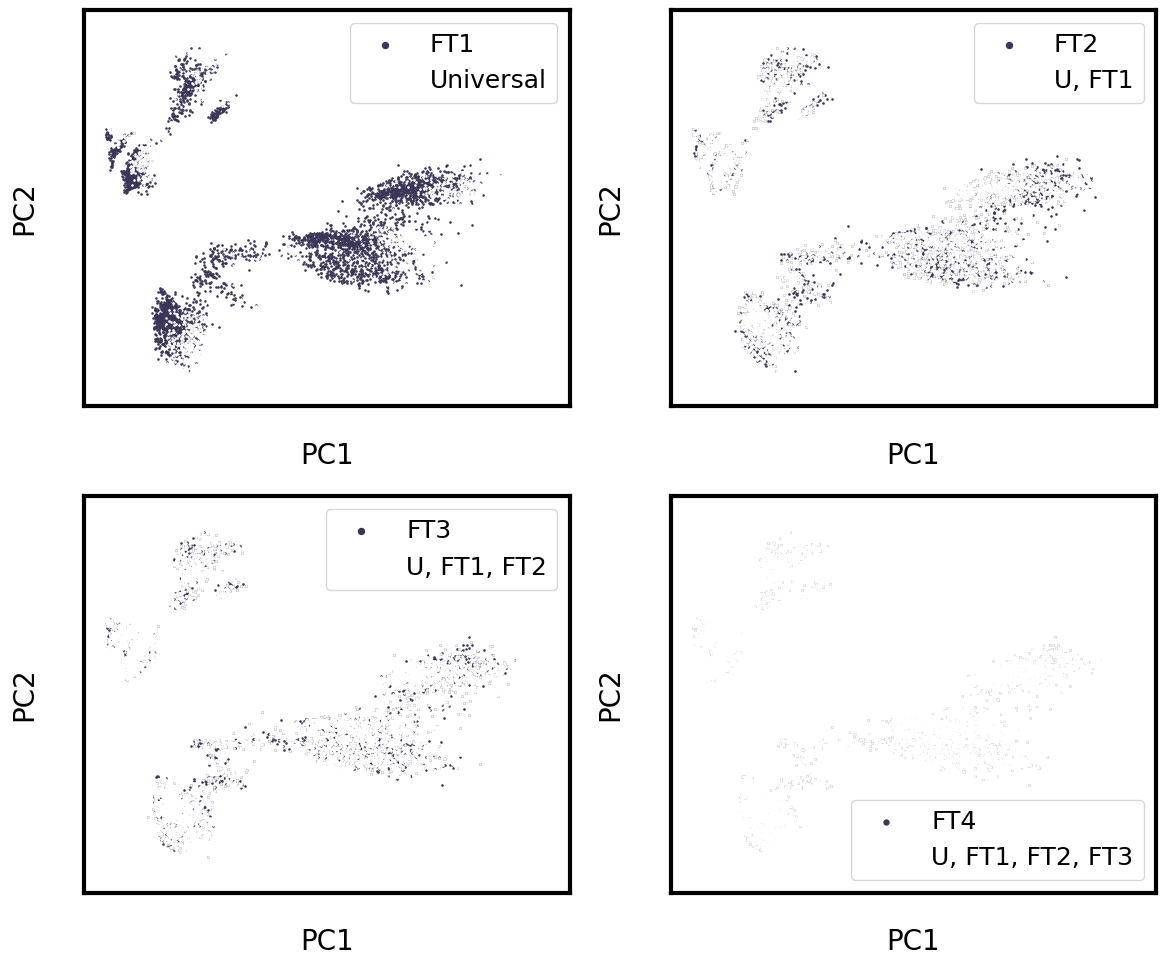

In [32]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# ---- Plot 1 ----
axes[0].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label="FT1",marker='.',rasterized=True)
axes[0].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white', label="Universal",marker='.',rasterized=True)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
# axes[0].set_title("U->FT1")

# ---- Plot 2 ----
axes[1].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label="FT2",marker='.',rasterized=True)
axes[1].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color='white', label="U, FT1",marker='.',rasterized=True)
axes[1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
# axes[1].set_title("FT1->FT2")

# ---- Plot 3 ----
axes[2].scatter(X_ft3_pca[:, 0], X_ft3_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label="FT3",marker='.',rasterized=True)
axes[2].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color='white', label="U, FT1, FT2",marker='.',rasterized=True)
axes[2].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[2].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
# axes[2].set_title("FT2->FT3")

# ---- Plot 4 ----

axes[3].scatter(X_ft4_pca[:, 0], X_ft4_pca[:, 1], 
                alpha=1, s=2, color=colors[5], label="FT4",marker='.',rasterized=True)
axes[3].scatter(X_ft3_pca[:, 0], X_ft3_pca[:, 1], 
                alpha=1, s=3, color='white', label="U, FT1, FT2, FT3",marker='.',rasterized=True)
axes[3].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[3].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[3].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color='white',marker='.',rasterized=True)
axes[3].set_xlabel("PC1")
axes[3].set_ylabel("PC2")
# axes[3].set_title("FT3->FT4")
axes[0].legend(markerscale=5)
axes[1].legend(markerscale=5)
axes[2].legend(markerscale=5)
axes[3].legend(markerscale=5)
for a in axes:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
fig.tight_layout()
fig.savefig("figures/results_PCA_per_iteration.svg")
fig.show()


# Long Trajectory Analysis

In [71]:
Periodic_Long_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Periodic/dft")
Naive_Long_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Naive/dft")
Periodic_Long_MD = pd.read_csv("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/run_info.txt", sep='\t')
Naive_Long_MD = pd.read_csv("../data/ChClCA_Evaluations/Long_Runs/Naive/md/run_info.txt", sep='\t')
Naive_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", "::100") + read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", '::100')
Periodic_traj = read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_1_ase.xyz", "::100")+read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_2_ase.xyz", '::100')

In [ ]:
periodic_on_naive = []
naive_on_periodic = []
meV_per_atom = 1000/197
for image in Naive_traj:
    image.calc = FT5_model
    periodic_on_naive.append(image.get_potential_energy()*meV_per_atom)
for image in Periodic_traj:
    image.calc = N_50pts_model
    naive_on_periodic.append(image.get_potential_energy()*meV_per_atom)


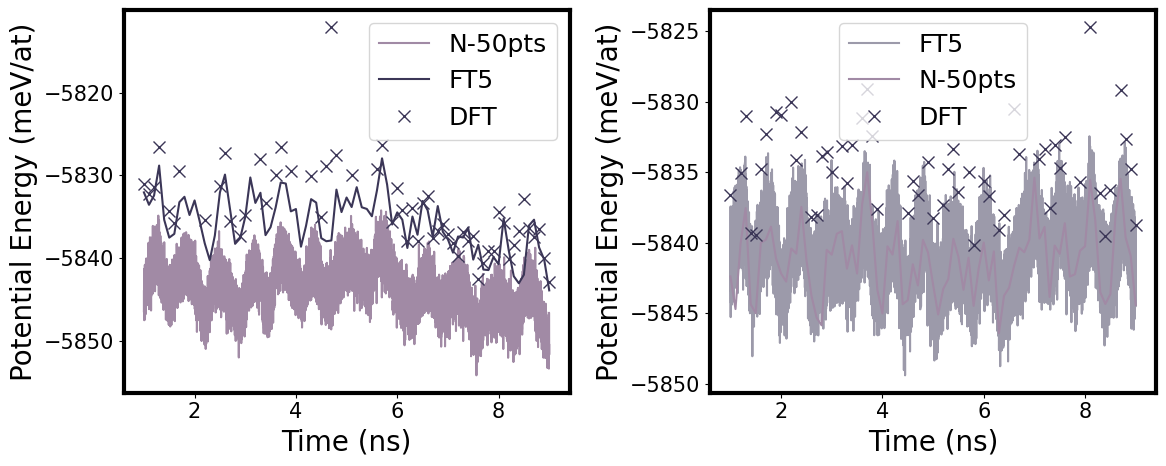

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
x_axis = np.linspace(0, 9, 18001)
ax[0].plot(x_axis[2000:], Naive_Long_MD['PotEng'][2000:] * meV_per_atom, color=colors[2], label='N-50pts')
ax[0].plot(x_axis[2000:][::200], periodic_on_naive[10:], color=colors[5], label='FT5')
keys, vals = zip(*Naive_Long_DFT.items())
energies = np.array([v.energy for v in vals])
ax[0].plot(np.array(keys)/2000, energies * meV_per_atom, 'x', color=colors[5], markersize=9, label='DFT')

ax[1].plot(x_axis[2000:], Periodic_Long_MD['PotEng'][2000:] * meV_per_atom, color=colors[5], alpha=0.5, label='FT5')
ax[1].plot(x_axis[2000:][::200], naive_on_periodic[10:], color=colors[2], label='N-50pts')
keys, vals = zip(*Periodic_Long_DFT.items())
energies = np.array([v.energy for v in vals])

ax[1].plot(np.array(keys)/2000, energies * meV_per_atom, 'x', color=colors[5], markersize=9, label='DFT')
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel("Time (ns)")
ax[1].set_xlabel("Time (ns)")
ax[0].set_ylabel("Potential Energy (meV/at)")
ax[1].set_ylabel("Potential Energy (meV/at)")
fig.tight_layout()
fig.savefig("figures/results_longEval.svg")

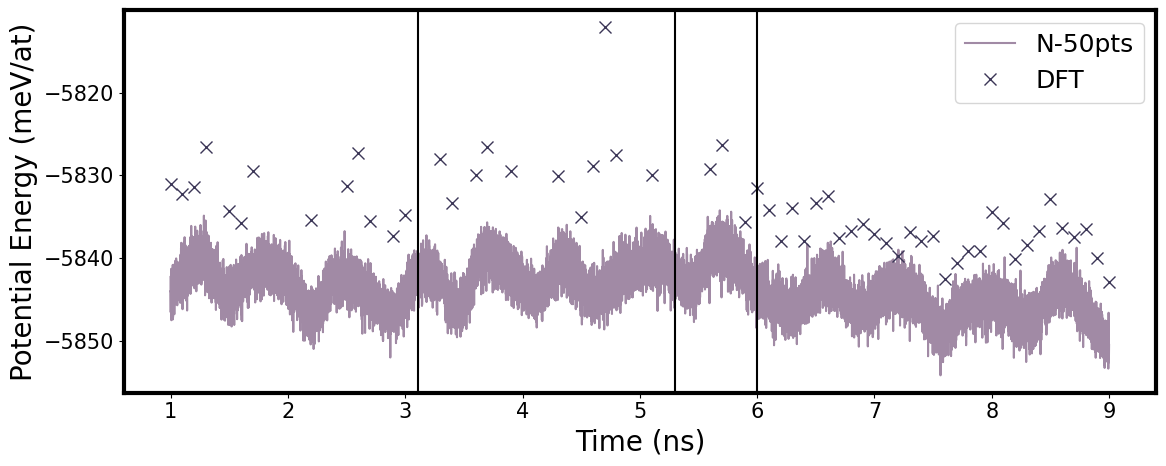

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (12, 5))
x_axis = np.linspace(0, 9, 18001)
ax.plot(x_axis[2000:], Naive_Long_MD['PotEng'][2000:] * meV_per_atom, color=colors[2], label='N-50pts')
# ax.plot(x_axis[2000:][::200], periodic_on_naive[10:], color=colors[5], label='FT5')
keys, vals = zip(*Naive_Long_DFT.items())
energies = np.array([v.energy for v in vals])
ax.plot(np.array(keys)/2000, energies * meV_per_atom, 'x', color=colors[5], markersize=9, label='DFT')
ax.axvline(3.110, color='black')
ax.axvline(5.3025, color='black')
ax.axvline(6, color='black')
ax.legend()
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Potential Energy (meV/at)")
fig.tight_layout()
fig.savefig("figures/results_longNaiveTraj.svg")

In [37]:
naive_eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in Naive_traj]
X_eval_naive = np.array(naive_eval_desc).reshape(-1, naive_eval_desc[0].shape[-1])
X_eval_naive_pca = pca.transform(X_eval_naive)
periodic_eval_desc   =  [soap.create(atoms, centers=atoms.get_positions()) for atoms in Periodic_traj]
X_eval_periodic = np.array(periodic_eval_desc).reshape(-1, periodic_eval_desc[0].shape[-1])
X_eval_periodic_pca = pca.transform(X_eval_periodic)

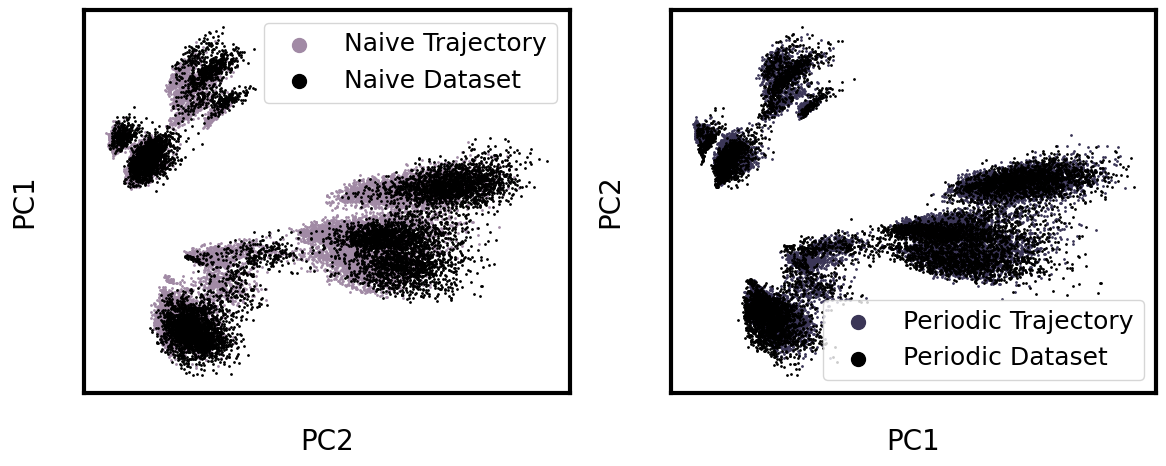

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(X_eval_naive_pca[:, 0], X_eval_naive_pca[:, 1],
           alpha=1, label="Naive Trajectory", s=1, color=colors[2], rasterized=True)
ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
ax[1].scatter(X_eval_periodic_pca[:, 0], X_eval_periodic_pca[:, 1],
           alpha=1, label="Periodic Trajectory", s=1, color=colors[5], rasterized=True)
ax[1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='black', 
           label='Periodic Dataset', rasterized=True)
for a in ax:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[0].set_xlabel("PC2")
ax[0].set_ylabel("PC1")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[0].legend(markerscale=10)
ax[1].legend(markerscale=10)
fig.show()
fig.tight_layout()
fig.savefig("figures/results_trajDatasets.svg")

# Q Residuals

In [88]:
def compute_q_residuals(pca, X):
    """
    Compute Q-residuals (orthogonal distances) for samples X
    given a fitted scikit-learn PCA model.
    """
    scores = pca.transform(X)
    X_reconstructed = np.dot(scores, pca.components_) + pca.mean_
    residuals = X - X_reconstructed
    q_residuals = np.sum(residuals**2, axis=1)
    return q_residuals
def q_residual_inputs(soap, pca_dataset, trajectory_eval):
    eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in trajectory_eval]
    eval_desc = np.array(eval_desc).reshape(-1, eval_desc[0].shape[-1])
    pca_set = [soap.create(atoms, centers=atoms.get_positions()) for atoms in pca_dataset]
    X_pca_set_set = np.array(pca_set).reshape(-1, pca_set[0].shape[-1])
    pca = PCA(n_components=5)
    X_pca = pca.fit_transform(X_pca_set_set)
    return pca, eval_desc
def plot_q_residuals(pca, eval_desc, colors, remapped):
    total_sum = 0
    num_slices = 197
    slice_length = 21
    for i in range(num_slices):
        residuals = compute_q_residuals(pca, eval_desc[i::num_slices])
        color = 'black' if i == 0 else colors[remapped[i]]
        plt.plot(residuals, color=color)
        total_sum += np.sum(residuals)
    average_residual = total_sum / num_slices / slice_length
    print(average_residual)
    return average_residual

## Training

In [ ]:
ft1_training_data = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data_raw.xyz", ":")
ft2_training_data = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data_raw.xyz", ":")
ft3_training_data = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data_raw.xyz", ":")
ft4_training_data = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data_raw.xyz", ":")
ft5_training_data = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", ":")
ft1_training_traj = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/md/FT1_ase.xyz", "::100")
ft2_training_traj = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/md/FT2_ase.xyz", "::100")
ft3_training_traj = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/md/FT3_ase.xyz", "::100")
ft4_training_traj = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/md/FT4_ase.xyz", "::100")
ft5_training_traj = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/md/FT5_ase.xyz", "::100")

In [89]:
ft1_pca, X_ft1_eval_desc = q_residual_inputs(soap, ft1_training_data, ft1_training_traj)
ft2_pca, X_ft2_eval_desc = q_residual_inputs(soap, ft2_training_data, ft2_training_traj)
ft3_pca, X_ft3_eval_desc = q_residual_inputs(soap, ft3_training_data, ft3_training_traj)
ft4_pca, X_ft4_eval_desc = q_residual_inputs(soap, ft4_training_data, ft4_training_traj)
ft5_pca, X_ft5_eval_desc = q_residual_inputs(soap, ft5_training_data, ft5_training_traj)

In [96]:
unique_vals = np.unique(ft1_training_data[0].arrays['numbers'])
mapping = {val: idx for idx, val in enumerate(unique_vals)}
remapped = np.array([mapping[v] for v in Naive_traj[51].arrays['numbers']])

11.641485025987972
8.282774093070966
8.535228788460856
8.32343945508088
8.864058574155683


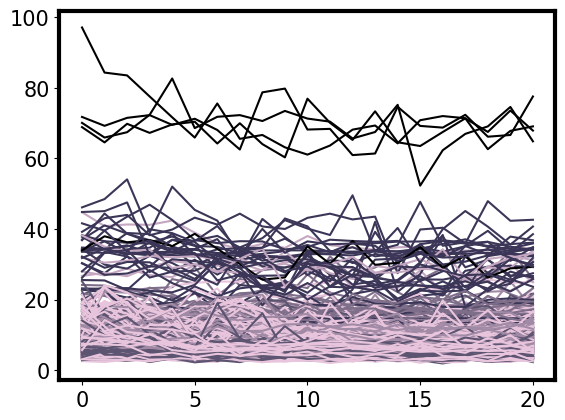

In [99]:
ft1_residual = plot_q_residuals(ft1_pca, X_ft1_eval_desc, colors, remapped)
ft2_residual = plot_q_residuals(ft2_pca, X_ft2_eval_desc, colors, remapped)
ft3_residual = plot_q_residuals(ft3_pca, X_ft3_eval_desc, colors, remapped)
ft4_residual = plot_q_residuals(ft4_pca, X_ft4_eval_desc, colors, remapped)
ft5_residual = plot_q_residuals(ft5_pca, X_ft5_eval_desc, colors, remapped)
ft_residuals = [ft1_residual, ft2_residual, ft3_residual, ft4_residual, ft5_residual]

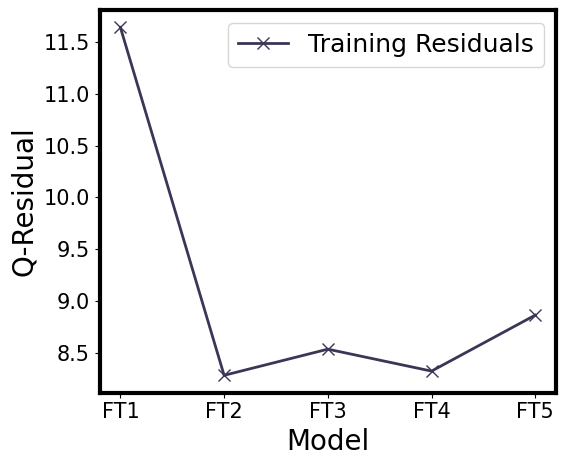

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.plot(ft_residuals , '-x', linewidth=2, markersize=8, label='Training Residuals', color=colors[5])
ax.set_xticks([0, 1, 2, 3, 4], ["FT1", "FT2", "FT3", "FT4", "FT5"])
ax.set_ylabel("Q-Residual")
ax.set_xlabel("Model")
ax.legend()
fig.tight_layout()
plt.savefig("figures/results_trainingQResiduals.svg")

## Testing

In [72]:
naive_eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in Naive_traj]
X_eval_naive = np.array(naive_eval_desc).reshape(-1, naive_eval_desc[0].shape[-1])
X_eval_naive_pca = pca.transform(X_eval_naive)
periodic_eval_desc   =  [soap.create(atoms, centers=atoms.get_positions()) for atoms in Periodic_traj]
X_eval_periodic = np.array(periodic_eval_desc).reshape(-1, periodic_eval_desc[0].shape[-1])
X_eval_periodic_pca = pca.transform(X_eval_periodic)

In [73]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft   = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])
naive_pca = PCA(n_components=5)
periodic_pca = PCA(n_components=5)
X_naive_pca = naive_pca.fit_transform(X_naive)
X_periodic_pca = periodic_pca.fit_transform(X_ft)


In [63]:
unique_vals = np.unique(Naive_traj[0].arrays['numbers'])
mapping = {val: idx for idx, val in enumerate(unique_vals)}
remapped = np.array([mapping[v] for v in Naive_traj[51].arrays['numbers']])

20.9164377470824
16.71653925866516


<Figure size 640x480 with 0 Axes>

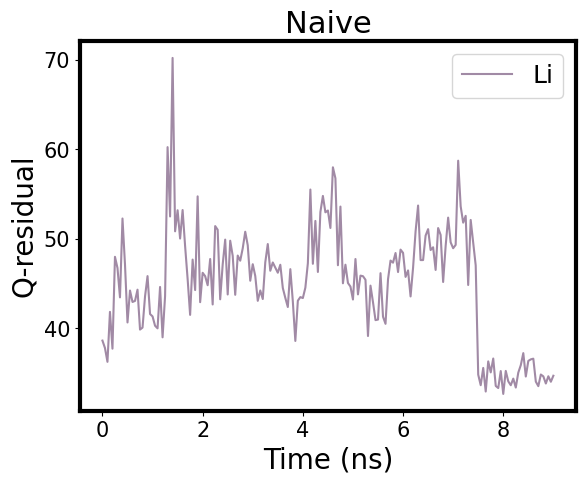

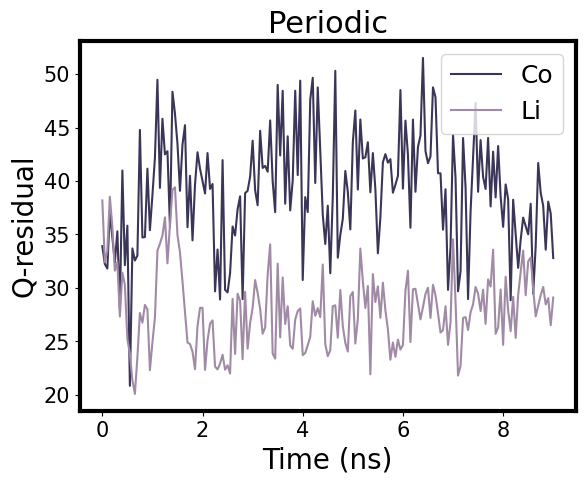

<Figure size 640x480 with 0 Axes>

In [ ]:

sum_1 = 0
time = np.linspace(0, 9, 181)
for i in range(197):
    if(remapped[i]==6):
        plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[5], label='Co')
        sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
    elif(remapped[i]==1):
        plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
        sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
    else:
        # plt.plot(compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[remapped[i]])
        sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
print(sum_1/197/91)
sum_2 = 0
plt.xlabel("Time (ns)")
plt.ylabel("Q-residual")
plt.title("Naive")
plt.legend()
plt.figure()
for i in range(197):
    if(remapped[i]==6):
        plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Co')
        sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
    elif(remapped[i]==1):
        plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
        sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
    else:
        # plt.plot(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[remapped[i]])
        sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
print(sum_2/197/91)
plt.xlabel("Time (ns)")
plt.title('Periodic')
plt.legend()
plt.ylabel("Q-residual")
plt.figure()

<Figure size 640x480 with 0 Axes>

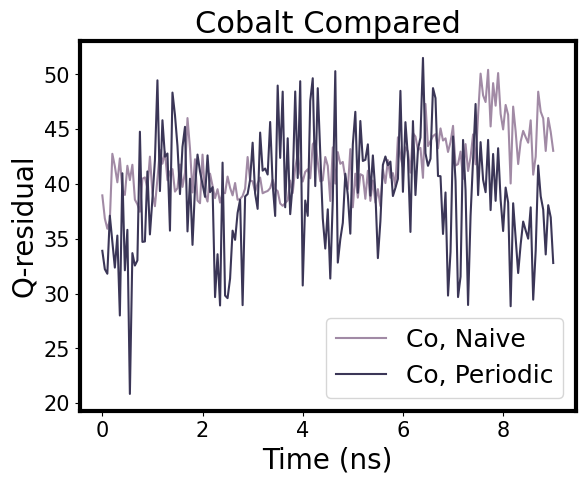

<Figure size 640x480 with 0 Axes>

In [77]:
time = np.linspace(0, 9, 181)
for i in range(197):
    if(remapped[i]==6):
        plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Co, Naive')
    # elif(remapped[i]==1):
    #     plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
for i in range(197):
    if(remapped[i]==6):
        plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Co, Periodic')
    # elif(remapped[i]==1):
    #     plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
plt.xlabel("Time (ns)")
plt.title('Cobalt Compared')
plt.legend()
plt.ylabel("Q-residual")
plt.figure()

<Figure size 640x480 with 0 Axes>

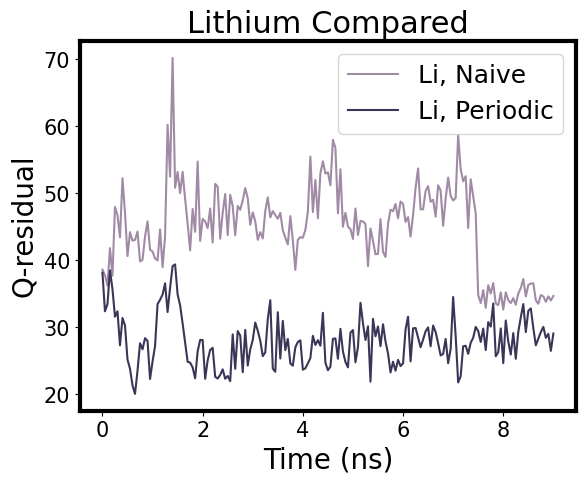

<Figure size 640x480 with 0 Axes>

In [78]:
time = np.linspace(0, 9, 181)
for i in range(197):
    if(remapped[i]==1):
        plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li, Naive')
    # elif(remapped[i]==1):
    #     plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
for i in range(197):
    if(remapped[i]==1):
        plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Li, Periodic')
    # elif(remapped[i]==1):
    #     plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
plt.xlabel("Time (ns)")
plt.title('Lithium Compared')
plt.legend()
plt.ylabel("Q-residual")
plt.figure()

In [113]:
# Model Dataset
N_10pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pt_dataset_raw.xyz", index=':')
N_21pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pt_dataset_raw.xyz", index=':')
N_31pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pt_dataset_raw.xyz", index=':')
N_40pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pt_dataset_raw.xyz", index=':')
N_50pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft1_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data_raw.xyz", index=":")
ft2_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data_raw.xyz", index=":")
ft3_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data_raw.xyz", index=":")
ft4_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data_raw.xyz", index=":")
ft5_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=":")
# Data generated
N_10pts_eval = read("../data/ChClCA_Evaluations/Naive/N-10pts/md/N-10pts_eval_ase.xyz", index='::100')
N_21pts_eval = read("../data/ChClCA_Evaluations/Naive/N-21pts/md/N-21pts_eval_ase.xyz", index='::100')
N_31pts_eval = read("../data/ChClCA_Evaluations/Naive/N-31pts/md/N-31pts_eval_ase.xyz", index='::100')
N_40pts_eval = read("../data/ChClCA_Evaluations/Naive/N-40pts/md/N-40pts_eval_ase.xyz", index='::100')
N_50pts_eval = read("../data/ChClCA_Evaluations/Naive/N-50pts/md/N-50pts_eval_ase.xyz", index='::100')
ft1_eval = read("../data/ChClCA_Evaluations/Periodic/FT1/md/ft1_eval_ase.xyz", index='::100')
ft2_eval = read("../data/ChClCA_Evaluations/Periodic/FT2/md/ft2_eval_ase.xyz", index='::100')
ft3_eval = read("../data/ChClCA_Evaluations/Periodic/FT3/md/ft3_eval_ase.xyz", index='::100')
ft4_eval = read("../data/ChClCA_Evaluations/Periodic/FT4/md/ft4_eval_ase.xyz", index='::100')
ft5_eval = read("../data/ChClCA_Evaluations/Periodic/FT5/md/ft5_eval_ase.xyz", index='::100')

In [114]:
n_10pt_pca, X_N_10pts_eval_desc = q_residual_inputs(soap, N_10pts_dataset, N_10pts_eval)
n_21pt_pca, X_N_21pts_eval_desc = q_residual_inputs(soap, N_21pts_dataset, N_21pts_eval)
n_31pt_pca, X_N_31pts_eval_desc = q_residual_inputs(soap, N_31pts_dataset, N_31pts_eval)
n_40pt_pca, X_N_40pts_eval_desc = q_residual_inputs(soap, N_40pts_dataset, N_40pts_eval)
n_50pt_pca, X_N_50pts_eval_desc = q_residual_inputs(soap, N_50pts_dataset, N_50pts_eval)

In [ ]:
ft1_pca, ft1_eval_desc = q_residual_inputs(soap, ft1_dataset, ft1_eval)
ft2_pca, ft2_eval_desc = q_residual_inputs(soap, ft2_dataset, ft2_eval)
ft3_pca, ft3_eval_desc = q_residual_inputs(soap, ft3_dataset, ft3_eval)
ft4_pca, ft4_eval_desc = q_residual_inputs(soap, ft4_dataset, ft4_eval)
ft5_pca, ft5_eval_desc = q_residual_inputs(soap, ft5_dataset, ft5_eval)

11.796175755069395
10.25266470603889
10.379979814232732
10.318876434653973
10.147046213346027


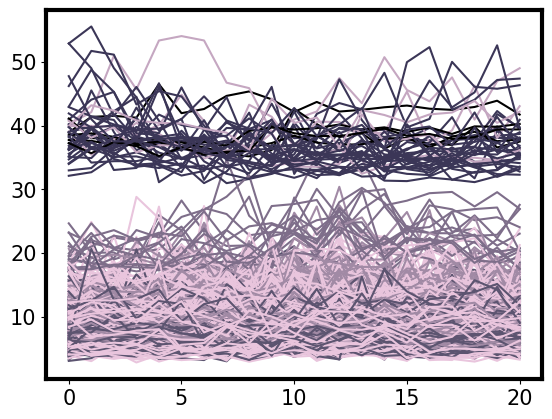

In [ ]:
n_10pt_residual = plot_q_residuals(n_10pt_pca, X_N_10pts_eval_desc, colors, remapped)
n_21pt_residual = plot_q_residuals(n_21pt_pca, X_N_21pts_eval_desc, colors, remapped)
n_31pt_residual = plot_q_residuals(n_31pt_pca, X_N_31pts_eval_desc, colors, remapped)
n_40pt_residual = plot_q_residuals(n_40pt_pca, X_N_40pts_eval_desc, colors, remapped)
n_50pt_residual = plot_q_residuals(n_50pt_pca, X_N_50pts_eval_desc, colors, remapped)
naive_residuals = [n_10pt_residual, n_21pt_residual, n_31pt_residual, n_40pt_residual, n_50pt_residual]

11.738848981799281
8.509619144303283
8.623027209232426
8.831009894882339
8.864058574155683


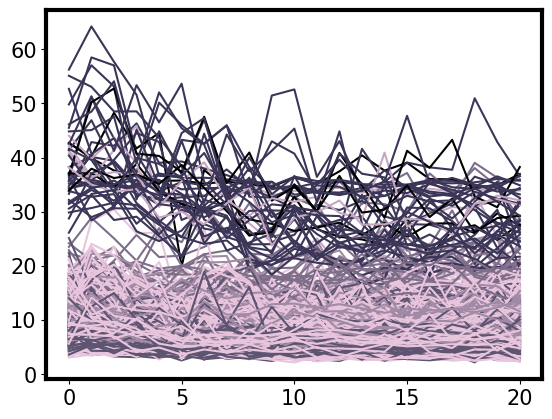

In [ ]:
ft1_residual = plot_q_residuals(ft1_pca, ft1_eval_desc, colors, remapped)
ft2_residual = plot_q_residuals(ft2_pca, ft2_eval_desc, colors, remapped)
ft3_residual = plot_q_residuals(ft3_pca, ft3_eval_desc, colors, remapped)
ft4_residual = plot_q_residuals(ft4_pca, ft4_eval_desc, colors, remapped)
ft5_residual = plot_q_residuals(ft5_pca, ft5_eval_desc, colors, remapped)
ft_residuals = [ft1_residual, ft2_residual, ft3_residual, ft4_residual, ft5_residual]

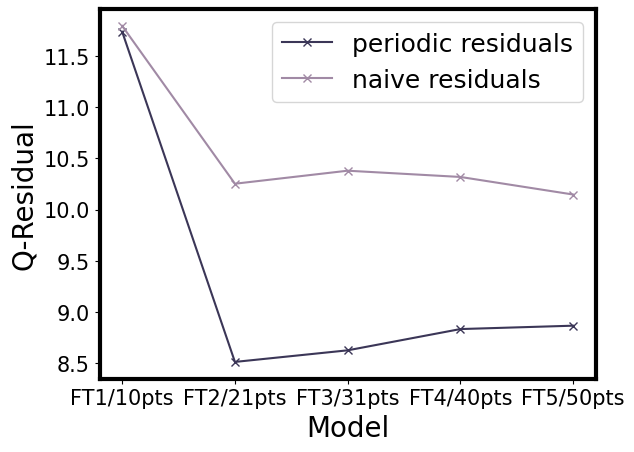

In [ ]:
plt.plot(ft_residuals , '-x', label='periodic residuals', color=colors[5])
plt.plot(naive_residuals, '-x', label='naive residuals', color=colors[2])
plt.xticks([0, 1, 2, 3, 4], ["FT1/10pts", "FT2/21pts", "FT3/31pts", "FT4/40pts", "FT5/50pts"])
plt.ylabel("Q-Residual")
plt.xlabel("Model")
plt.legend()

## Reaction Projections

In [50]:
naive_reacted_images = read("./data_subsets/naive_reacted_images.xyz", index=":")
naive_reacted_eval_desc   = [soap.create(atoms, centers=atoms.get_positions(wrap=True)) for atoms in naive_reacted_images]
X_eval_naive_reacted = np.array(naive_reacted_eval_desc).reshape(-1, naive_reacted_eval_desc[0].shape[-1])
X_eval_naive_reacted_pca = pca.transform(X_eval_naive_reacted)
periodic_reacted_images = read("./data_subsets/periodic_reacted_images.xyz", index=":")
periodic_reacted_eval_desc   = [soap.create(atoms, centers=atoms.get_positions(wrap=True)) for atoms in periodic_reacted_images]
X_eval_periodic_reacted = np.array(periodic_reacted_eval_desc).reshape(-1, periodic_reacted_eval_desc[0].shape[-1])
X_eval_periodic_reacted_pca = pca.transform(X_eval_periodic_reacted)
X_eval_naive_reacted_pca = X_eval_naive_reacted_pca.reshape(4, 197, 2)
X_eval_periodic_reacted_pca = X_eval_periodic_reacted_pca.reshape(50, 197, 2)

In [51]:
first_range = []
for i in range(0,4):
    first_range.extend(np.where(naive_reacted_images[i].arrays['id']==123)[0])
second_range = []
for i in range(4,50):
    second_range.extend(np.where(periodic_reacted_images[i].arrays['id']==186)[0])


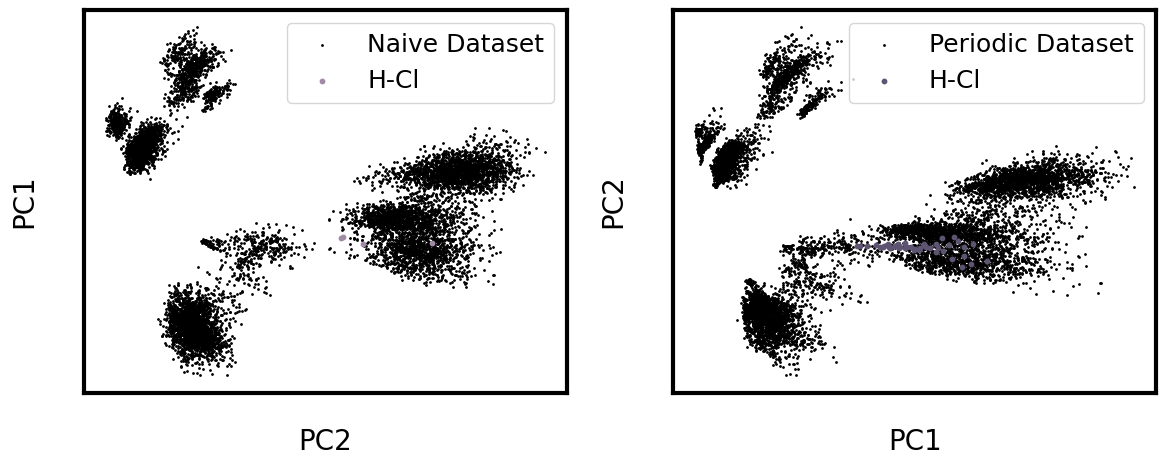

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# ax[0].scatter(X_eval_naive_pca[:, 0], X_eval_naive_pca[:, 1],
#            alpha=1, label="Naive Trajectory", s=1, color=colors[0], rasterized=True)
ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
for i in range(0,4):
    ax[0].scatter(X_eval_naive_reacted_pca[i, first_range[i], 0], X_eval_naive_reacted_pca[i, first_range[i], 1],
                alpha=1, s=10, rasterized=True, color=colors[2], label="H-Cl" if i == 0 else "_nolegend_")
ax[1].scatter(X_eval_periodic_reacted_pca[:, :, 0], X_eval_periodic_reacted_pca[:, :, 1], s=1, alpha=1, color='black', 
           label='Periodic Dataset', rasterized=True)
for i in range(4, 50):
    ax[1].scatter(X_eval_periodic_reacted_pca[i, second_range[i-4], 0], X_eval_periodic_reacted_pca[i, second_range[i-4], 1], 
                  s=10, alpha=1, rasterized=True, color=colors[4], label="H-Cl" if i == 4 else "_nolegend_")
# for i in range(7, 18):
#     ax[0].scatter(X_eval_naive_reacted_pca[i, second_range[i-7], 0], X_eval_naive_reacted_pca[i, second_range[i-7], 1],
#                   alpha=1, s=10, color=colors[0], rasterized=True)
# ax[1].scatter(X_eval_periodic_pca[:, 0], X_eval_periodic_pca[:, 1],
#            alpha=1, label="Periodic Trajectory", s=1, color=colors[1], rasterized=True)
for a in ax:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))

ax[0].set_xlabel("PC2")
ax[0].set_ylabel("PC1")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[0].legend(markerscale=1)
ax[1].legend(markerscale=1)
fig.tight_layout()
fig.savefig("./figures/results_pcaHClReaction.svg")

In [53]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
species = set()
for atoms in naive_set:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)

In [54]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
naive_pca = PCA(n_components=2)
X_naive_pca = naive_pca.fit_transform(X_naive)


In [55]:
reaction_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", index="6520:6535")
reaction_2_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", index="1605:1615")

In [56]:
reaction_occuring_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in reaction_traj]
X_rxn = np.array(reaction_occuring_desc).reshape(-1, reaction_occuring_desc[0].shape[-1])
X_rxn_pca = naive_pca.transform(X_rxn)
X_rxn_pca = X_rxn_pca.reshape(15, 197, 2)
reaction_2_occuring_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in reaction_2_traj]
X_rxn_2 = np.array(reaction_2_occuring_desc).reshape(-1, reaction_2_occuring_desc[0].shape[-1])
X_rxn_2_pca = naive_pca.transform(X_rxn_2)
X_rxn_2_pca = X_rxn_2_pca.reshape(10, 197, 2)

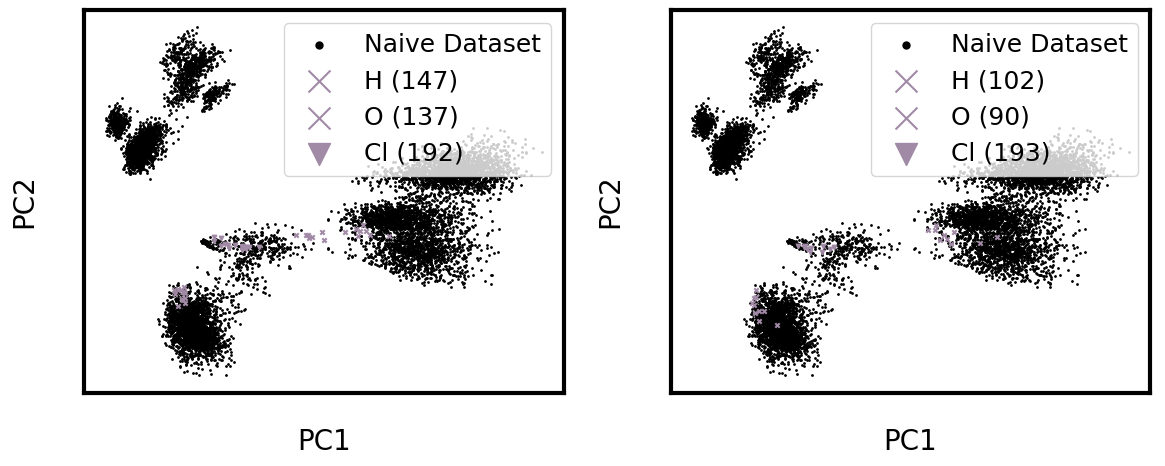

In [57]:
# ---- 3D Plot ----
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
ax[0].scatter(X_rxn_pca[:, 146, 0], X_rxn_pca[:, 146, 1],
           alpha=1, label="H (147)", marker='x', s=10, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_pca[:, 136, 0], X_rxn_pca[:, 136, 1],
           alpha=1, label="O (137)", marker='x', s=10, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_pca[:, 191, 0], X_rxn_pca[:, 191, 1],
           alpha=1, label="Cl (192)", s=10, marker='v', color=colors[2], rasterized=True)
ax[1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
ax[1].scatter(X_rxn_2_pca[:, 101, 0], X_rxn_2_pca[:, 101, 1],
           alpha=1, label="H (102)", marker='x', s=10, color=colors[2], rasterized=True)
ax[1].scatter(X_rxn_2_pca[:, 89, 0], X_rxn_2_pca[:, 89, 1],
           alpha=1, label="O (90)", marker='x', s=10, color=colors[2], rasterized=True)
ax[1].scatter(X_rxn_2_pca[:, 192, 0], X_rxn_2_pca[:, 192, 1],
           alpha=1, label="Cl (193)", s=10, marker='v', color=colors[2], rasterized=True)

ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].legend(markerscale=5, loc='upper right')
ax[1].legend(markerscale=5, loc='upper right')
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

for a in ax:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
fig.tight_layout()
plt.savefig("figures/results_HClReactions.svg")
plt.show()